In [10]:
import os
print(os.getcwd())
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

C:\Users\user


In [11]:
import warnings
warnings.filterwarnings('ignore')


In [12]:
# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [14]:
import zipfile

with zipfile.ZipFile("ml-major/shill+bidding+dataset.zip", "r") as z:
    z.extractall("ml-major/shill_data")

In [16]:
import pandas as pd

df = pd.read_csv(
    "ml-major/shill+bidding+dataset.zip",
    compression="zip"
)

print(df.head())
print(df.shape)
print(df.columns.tolist())

   Record_ID  Auction_ID Bidder_ID  Bidder_Tendency  Bidding_Ratio  \
0          1         732     _***i         0.200000       0.400000   
1          2         732     g***r         0.024390       0.200000   
2          3         732     t***p         0.142857       0.200000   
3          4         732     7***n         0.100000       0.200000   
4          5         900     z***z         0.051282       0.222222   

   Successive_Outbidding  Last_Bidding  Auction_Bids  Starting_Price_Average  \
0                    0.0      0.000028           0.0                0.993593   
1                    0.0      0.013123           0.0                0.993593   
2                    0.0      0.003042           0.0                0.993593   
3                    0.0      0.097477           0.0                0.993593   
4                    0.0      0.001318           0.0                0.000000   

   Early_Bidding  Winning_Ratio  Auction_Duration  Class  
0       0.000028       0.666667        

In [22]:

print("1. DATASET DIMENSIONS")
print("="*80)
print(f"Number of Records: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

print("2. FEATURE DESCRIPTIONS")
print("="*80)
print(df.columns.tolist())

# Display first few rows
print("\nFirst 5 Records:")
print(df.head())


print("3. DATA TYPES")
print("="*80)
print(df.dtypes)


print("4. MISSING VALUES ANALYSIS")
print("="*80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

if len(missing_data) == 0:
    print("No missing values detected!")
else:
    print(missing_data)


print("5. DUPLICATE RECORDS")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")


print("6. CLASS DISTRIBUTION (Target Variable)")


# Assuming the target variable is named 'Class' or similar
# Adjust based on actual dataset structure
target_col = 'Class' if 'Class' in df.columns else df.columns[-1]

print(f"\nTarget Variable: {target_col}")
class_distribution = df[target_col].value_counts()
print("\nClass Distribution:")
print(class_distribution)
print("\nClass Percentage:")
print((class_distribution / len(df)) * 100)

# Calculate imbalance ratio
majority_class = class_distribution.max()
minority_class = class_distribution.min()
imbalance_ratio = majority_class / minority_class
print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("WARNING: Significant class imbalance detected!")
    print(" Recommendation: Use SMOTE, class weights, or stratified sampling")


print("7. STATISTICAL SUMMARY")

print(df.describe())

print("8. FEATURE CORRELATION ANALYSIS")
# Compute correlation matrix
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Find highly correlated features (threshold: 0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("\ Highly Correlated Features (|r| > 0.8):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df)
    print("\n→ Recommendation: Consider removing one feature from each pair")
else:
    print("No highly correlated features detected")

print("9. OUTLIER DETECTION (IQR Method)")

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), (len(outliers)/len(data))*100

outlier_summary = []
for col in numerical_cols:
    if col != target_col:
        count, percentage = detect_outliers_iqr(df, col)
        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': count,
            'Outlier_Percentage': percentage
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    'Outlier_Percentage', ascending=False
)
print(outlier_df)

print("\n Outlier Interpretation:")
print("In fraud detection, outliers may represent fraudulent behavior")
print("DO NOT blindly remove - analyze contextually")

print("10. DATA QUALITY REPORT")

data_quality_score = 100
issues = []

if duplicates > 0:
    data_quality_score -= 10
    issues.append(f"Duplicate records: {duplicates}")

if len(missing_data) > 0:
    data_quality_score -= 15
    issues.append(f"Missing values in {len(missing_data)} columns")

if imbalance_ratio > 5:
    data_quality_score -= 20
    issues.append(f"Severe class imbalance: {imbalance_ratio:.2f}:1")

if len(high_corr_pairs) > 0:
    data_quality_score -= 10
    issues.append(f"{len(high_corr_pairs)} highly correlated feature pairs")

print(f"\n DATA QUALITY SCORE: {data_quality_score}/100")

if issues:
    print("\n Issues Detected:")
    for i, issue in enumerate(issues, 1):
        print(f"   {i}. {issue}")
else:
    print("\n✓ No major data quality issues detected!")


1. DATASET DIMENSIONS
Number of Records: 6321
Number of Features: 13

2. FEATURE DESCRIPTIONS
['Record_ID', 'Auction_ID', 'Bidder_ID', 'Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Starting_Price_Average', 'Early_Bidding', 'Winning_Ratio', 'Auction_Duration', 'Class']

First 5 Records:
   Record_ID  Auction_ID Bidder_ID  Bidder_Tendency  Bidding_Ratio  \
0          1         732     _***i         0.200000       0.400000   
1          2         732     g***r         0.024390       0.200000   
2          3         732     t***p         0.142857       0.200000   
3          4         732     7***n         0.100000       0.200000   
4          5         900     z***z         0.051282       0.222222   

   Successive_Outbidding  Last_Bidding  Auction_Bids  Starting_Price_Average  \
0                    0.0      0.000028           0.0                0.993593   
1                    0.0      0.013123           0.0                0.993593   
2  

In [23]:
print(f"Number of Records: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

Number of Records: 6321
Number of Features: 13


In [24]:
print(df.columns.tolist())
print(df.head())

['Record_ID', 'Auction_ID', 'Bidder_ID', 'Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Auction_Bids', 'Starting_Price_Average', 'Early_Bidding', 'Winning_Ratio', 'Auction_Duration', 'Class']
   Record_ID  Auction_ID Bidder_ID  Bidder_Tendency  Bidding_Ratio  \
0          1         732     _***i         0.200000       0.400000   
1          2         732     g***r         0.024390       0.200000   
2          3         732     t***p         0.142857       0.200000   
3          4         732     7***n         0.100000       0.200000   
4          5         900     z***z         0.051282       0.222222   

   Successive_Outbidding  Last_Bidding  Auction_Bids  Starting_Price_Average  \
0                    0.0      0.000028           0.0                0.993593   
1                    0.0      0.013123           0.0                0.993593   
2                    0.0      0.003042           0.0                0.993593   
3                    0.0      0.0974

In [25]:
print(df.dtypes)

Record_ID                   int64
Auction_ID                  int64
Bidder_ID                     str
Bidder_Tendency           float64
Bidding_Ratio             float64
Successive_Outbidding     float64
Last_Bidding              float64
Auction_Bids              float64
Starting_Price_Average    float64
Early_Bidding             float64
Winning_Ratio             float64
Auction_Duration            int64
Class                       int64
dtype: object


In [26]:
df.isnull().sum()

Record_ID                 0
Auction_ID                0
Bidder_ID                 0
Bidder_Tendency           0
Bidding_Ratio             0
Successive_Outbidding     0
Last_Bidding              0
Auction_Bids              0
Starting_Price_Average    0
Early_Bidding             0
Winning_Ratio             0
Auction_Duration          0
Class                     0
dtype: int64

In [29]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

Number of duplicate rows: 0


In [30]:
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False
)

if len(missing_data) == 0:
    print("No missing values detected!")
else:
    print(missing_data)

No missing values detected!


In [33]:
target_col = 'Class'
class_distribution = df[target_col].value_counts()


In [38]:
target_col = 'Class' if 'Class' in df.columns else df.columns[-1]

print(f"\nTarget Variable: {target_col}")
class_distribution = df[target_col].value_counts()
print("\nClass Distribution:")
print(class_distribution)
print("\nClass Percentage:")
print((class_distribution / len(df)) * 100)

# Calculate imbalance ratio
majority_class = class_distribution.max()
minority_class = class_distribution.min()
imbalance_ratio = majority_class / minority_class
print(f"\n Imbalance Ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 3:
    print("WARNING")
    


Target Variable: Class

Class Distribution:
Class
0    5646
1     675
Name: count, dtype: int64

Class Percentage:
Class
0    89.32131
1    10.67869
Name: count, dtype: float64

 Imbalance Ratio: 8.36:1
WARNING


In [35]:
print(df.describe())

          Record_ID   Auction_ID  Bidder_Tendency  Bidding_Ratio  \
count   6321.000000  6321.000000      6321.000000    6321.000000   
mean    7535.829457  1241.388230         0.142541       0.127670   
std     4364.759137   735.770789         0.197084       0.131530   
min        1.000000     5.000000         0.000000       0.011765   
25%     3778.000000   589.000000         0.027027       0.043478   
50%     7591.000000  1246.000000         0.062500       0.083333   
75%    11277.000000  1867.000000         0.166667       0.166667   
max    15144.000000  2538.000000         1.000000       1.000000   

       Successive_Outbidding  Last_Bidding  Auction_Bids  \
count            6321.000000   6321.000000   6321.000000   
mean                0.103781      0.463119      0.231606   
std                 0.279698      0.380097      0.255252   
min                 0.000000      0.000000      0.000000   
25%                 0.000000      0.047928      0.000000   
50%                 0.00000

In [40]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Find highly correlated features (threshold: 0.8)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append({
                'Feature_1': correlation_matrix.columns[i],
                'Feature_2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print(" Highly Correlated Features (|r| > 0.8):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df)
else:
    print("No highly correlated features detected")


 Highly Correlated Features (|r| > 0.8):
       Feature_1              Feature_2  Correlation
0  Early_Bidding           Last_Bidding     0.950096
1          Class  Successive_Outbidding     0.901035


In [42]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), (len(outliers)/len(data))*100

outlier_summary = []
for col in numerical_cols:
    if col != target_col:
        count, percentage = detect_outliers_iqr(df, col)
        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': count,
            'Outlier_Percentage': percentage
        })

outlier_df = pd.DataFrame(outlier_summary).sort_values(
    'Outlier_Percentage', ascending=False
)
print(outlier_df)




                   Feature  Outlier_Count  Outlier_Percentage
4    Successive_Outbidding            843           13.336497
2          Bidder_Tendency            628            9.935137
3            Bidding_Ratio            430            6.802721
1               Auction_ID              0            0.000000
0                Record_ID              0            0.000000
5             Last_Bidding              0            0.000000
6             Auction_Bids              0            0.000000
7   Starting_Price_Average              0            0.000000
8            Early_Bidding              0            0.000000
9            Winning_Ratio              0            0.000000
10        Auction_Duration              0            0.000000


Visualizations saved as 'dataset_exploration.png'


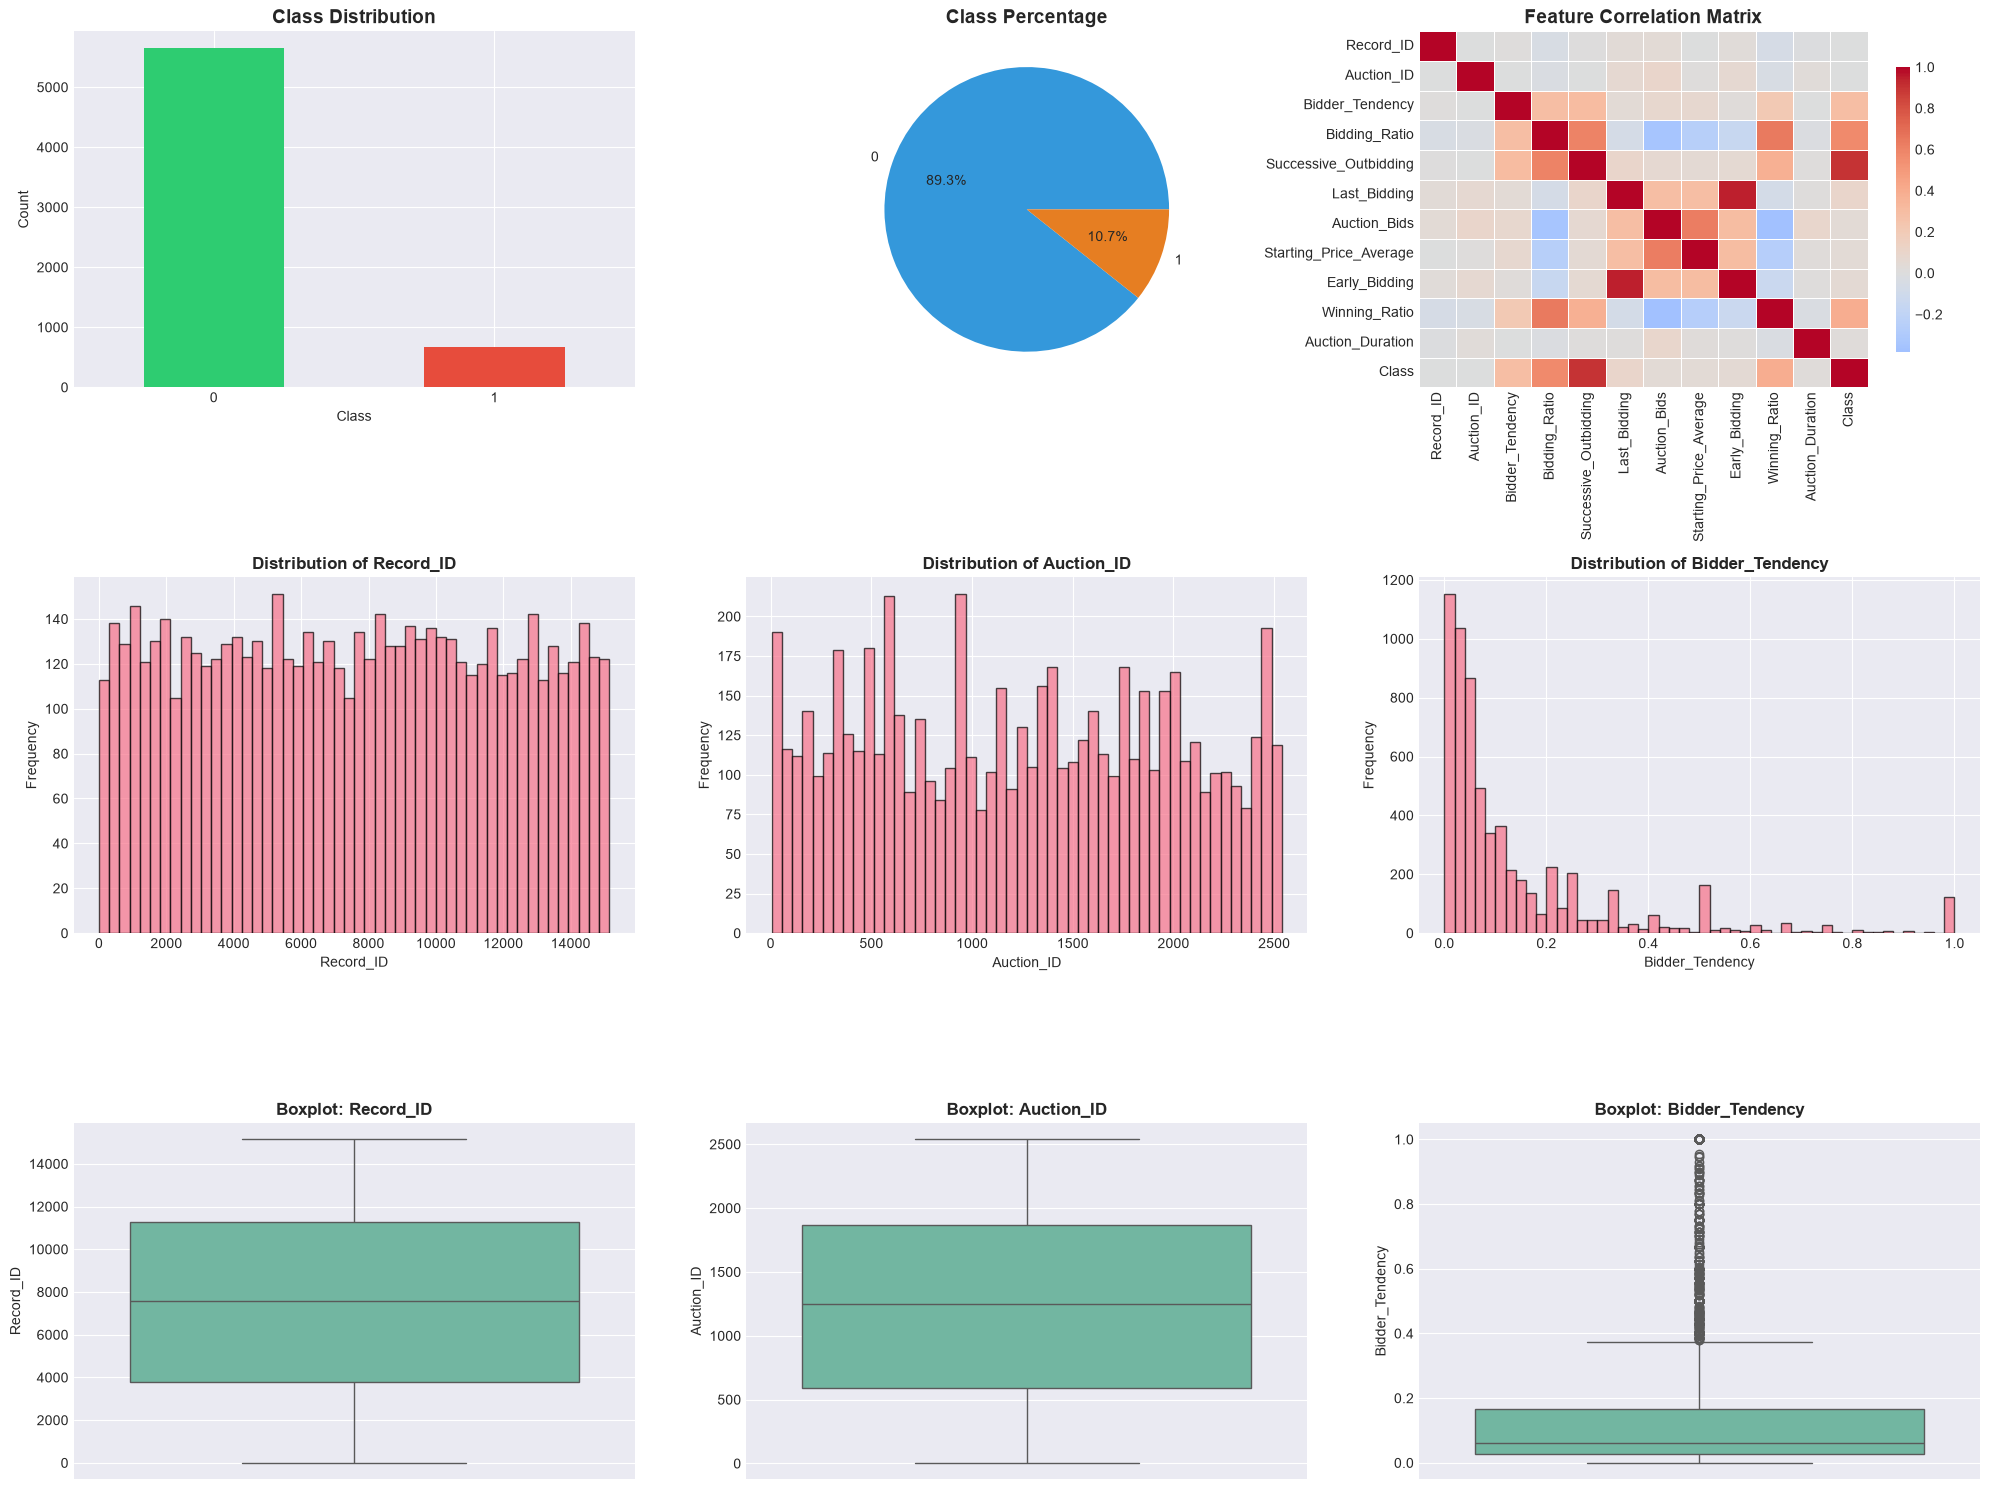

In [53]:

fig = plt.figure(figsize=(20, 15))

# Class Distribution
ax1 = plt.subplot(3, 3, 1)
df[target_col].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

#Class Distribution (Pie Chart)
ax2 = plt.subplot(3, 3, 2)
df[target_col].value_counts().plot(kind='pie', autopct='%1.1f%%', 
                                    colors=['#3498db', '#e67e22'])
plt.title('Class Percentage', fontsize=14, fontweight='bold')
plt.ylabel('')

# Correlation Heatmap
ax3 = plt.subplot(3, 3, 3)
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

# Distribution of key features
feature_cols = [col for col in numerical_cols if col != target_col][:3]
for idx, col in enumerate(feature_cols, 4):
    ax = plt.subplot(3, 3, idx)
    df[col].hist(bins=50, edgecolor='black', alpha=0.7)
    plt.title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Boxplots for outlier visualizatio
for idx, col in enumerate(feature_cols, 7):
    ax = plt.subplot(3, 3, idx)
    sns.boxplot(data=df, y=col, palette='Set2')
    plt.title(f'Boxplot: {col}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_exploration.png', dpi=300, bbox_inches='tight')
print("Visualizations saved as 'dataset_exploration.png'")
plt.show()

In [57]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler

In [58]:
# Create a copy for cleaning
df_clean = df.copy()
initial_shape = df_clean.shape

print(f"\nInitial Dataset: {initial_shape[0]} rows × {initial_shape[1]} columns")


Initial Dataset: 6321 rows × 13 columns


In [61]:
missing_before = df_clean.isnull().sum().sum()

if missing_before > 0:
    print(f"\nTotal missing values: {missing_before}")
    
    # Strategy 1: Drop columns with >50% missing data
    threshold = 0.5
    missing_ratio = df_clean.isnull().sum() / len(df_clean)
    cols_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
    
    if cols_to_drop:
        print(f"\n⚠ Dropping columns with >{threshold*100}% missing data:")
        print(f"   {cols_to_drop}")
        df_clean.drop(columns=cols_to_drop, inplace=True)
    
    # Strategy 2: Impute numerical features
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    numerical_missing = df_clean[numerical_cols].isnull().sum()
    numerical_missing = numerical_missing[numerical_missing > 0]
    
    if len(numerical_missing) > 0:
        print(f"\n✓ Imputing {len(numerical_missing)} numerical features using median strategy")
        imputer = SimpleImputer(strategy='median')
        df_clean[numerical_missing.index] = imputer.fit_transform(
            df_clean[numerical_missing.index]
        )
    
    # Strategy 3: Impute categorical features
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    categorical_missing = df_clean[categorical_cols].isnull().sum()
    categorical_missing = categorical_missing[categorical_missing > 0]
    
    if len(categorical_missing) > 0:
        print(f" Imputing {len(categorical_missing)} categorical features using mode strategy")
        for col in categorical_missing.index:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
    
    missing_after = df_clean.isnull().sum().sum()
    print(f"\n Missing values reduced from {missing_before} to {missing_after}")
else:
    print("\n No missing values found!")



 No missing values found!


In [63]:
duplicates_before = df_clean.duplicated().sum()

if duplicates_before > 0:
    print(f"\nFound {duplicates_before} duplicate rows")
    df_clean.drop_duplicates(inplace=True)
    print(f" Removed {duplicates_before} duplicates")
    print(f" New shape: {df_clean.shape}")
else:
    print("\n No duplicate records found!")


# Ensure target variable is integer
if target_col in df_clean.columns:
    df_clean[target_col] = df_clean[target_col].astype(int)
    print(f" Target variable '{target_col}' converted to integer")

# Convert any object columns that should be numeric
for col in df_clean.select_dtypes(include=['object']).columns:
    try:
        df_clean[col] = pd.to_numeric(df_clean[col])
        print(f" Converted '{col}' from object to numeric")
    except:
        pass

print(f"\n Final data types:")
print(df_clean.dtypes)




 No duplicate records found!
 Target variable 'Class' converted to integer

 Final data types:
Record_ID                   int64
Auction_ID                  int64
Bidder_ID                     str
Bidder_Tendency           float64
Bidding_Ratio             float64
Successive_Outbidding     float64
Last_Bidding              float64
Auction_Bids              float64
Starting_Price_Average    float64
Early_Bidding             float64
Winning_Ratio             float64
Auction_Duration            int64
Class                       int64
dtype: object


In [65]:
def analyze_outliers(data, column, target):
    """
    Analyze if outliers represent fraud or natural variation
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_mask = (data[column] < lower_bound) | (data[column] > upper_bound)
    outliers = data[outlier_mask]
    
    if len(outliers) > 0:
        # Check fraud rate in outliers vs normal data
        fraud_rate_outliers = outliers[target].mean()
        fraud_rate_normal = data[~outlier_mask][target].mean()
        
        return {
            'feature': column,
            'outlier_count': len(outliers),
            'outlier_percentage': (len(outliers)/len(data))*100,
            'fraud_rate_in_outliers': fraud_rate_outliers,
            'fraud_rate_in_normal': fraud_rate_normal,
            'outliers_are_fraud_indicators': fraud_rate_outliers > fraud_rate_normal * 1.5
        }
    return None

outlier_analysis = []
numerical_features = [col for col in df_clean.select_dtypes(include=[np.number]).columns 
                      if col != target_col]

for col in numerical_features:
    result = analyze_outliers(df_clean, col, target_col)
    if result:
        outlier_analysis.append(result)

outlier_df = pd.DataFrame(outlier_analysis)

if len(outlier_df) > 0:
    print("\nOutlier Contextual Analysis:")
    print(outlier_df[['feature', 'outlier_percentage', 'outliers_are_fraud_indicators']])
    
    print("\n Outlier Handling Strategy:")
    fraud_indicator_features = outlier_df[
        outlier_df['outliers_are_fraud_indicators'] == True
    ]['feature'].tolist()
    
    if fraud_indicator_features:
        print(f"\n Features where outliers indicate fraud (KEEP outliers):")
        for feat in fraud_indicator_features:
            print(f"   - {feat}")
    
    normal_variation_features = outlier_df[
        outlier_df['outliers_are_fraud_indicators'] == False
    ]['feature'].tolist()
    
    if normal_variation_features:
        print(f"\n Features where outliers are natural variation (consider capping):")
        for feat in normal_variation_features:
            print(f"   - {feat}")
            # Apply robust scaling instead of removing
else:
    print("\n No significant outliers detected!")


final_shape = df_clean.shape

print(f"\n Cleaning Summary:")
print(f" Initial: {initial_shape[0]} rows × {initial_shape[1]} columns")
print(f" Final:   {final_shape[0]} rows × {final_shape[1]} columns")
print(f" Rows removed: {initial_shape[0] - final_shape[0]}")
print(f" Columns removed: {initial_shape[1] - final_shape[1]}")

# Check for any remaining issues
print(f" Final Data Quality Checks:")
print(f" Missing values: {df_clean.isnull().sum().sum()} ")
print(f" Duplicate rows: {df_clean.duplicated().sum()} ")
print(f" Data types consistent: okay")

# Save cleaned dataset
df_clean.to_csv('cleaned_shill_bidding_dataset.csv', index=False)
print(f" Cleaned dataset saved as 'cleaned_shill_bidding_dataset.csv'")



Outlier Contextual Analysis:
                 feature  outlier_percentage  outliers_are_fraud_indicators
0        Bidder_Tendency            9.935137                           True
1          Bidding_Ratio            6.802721                           True
2  Successive_Outbidding           13.336497                           True

 Outlier Handling Strategy:

 Features where outliers indicate fraud (KEEP outliers):
   - Bidder_Tendency
   - Bidding_Ratio
   - Successive_Outbidding

 Cleaning Summary:
 Initial: 6321 rows × 13 columns
 Final:   6321 rows × 13 columns
 Rows removed: 0
 Columns removed: 0
 Final Data Quality Checks:
 Missing values: 0 
 Duplicate rows: 0 
 Data types consistent: okay
 Cleaned dataset saved as 'cleaned_shill_bidding_dataset.csv'
